<a href="https://colab.research.google.com/github/mennashahin129-beep/House-Price-Prediction-System/blob/main/House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv('/content/Bengaluru_House_Data.csv')
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
data = data.dropna()

In [ ]:
# Extract the number of bedrooms from the 'size' column using regex
data["BHK"] = data["size"].str.extract(r'(\d+)')
# Drop rows where 'BHK' is NaN (i.e., size didn't contain a number)
data.dropna(subset=['BHK'], inplace=True)
# Convert the 'BHK' column to integer type for numerical analysis
data["BHK"] = data["BHK"].astype(int)

In [ ]:
def convert_sqft(x):

    if "-" in str(x):
        a,b = x.split("-")
        return (float(a)+float(b))/2

    try:
        return float(x)

    except:
        return None

In [ ]:
data["total_sqft"] = data["total_sqft"].apply(convert_sqft)

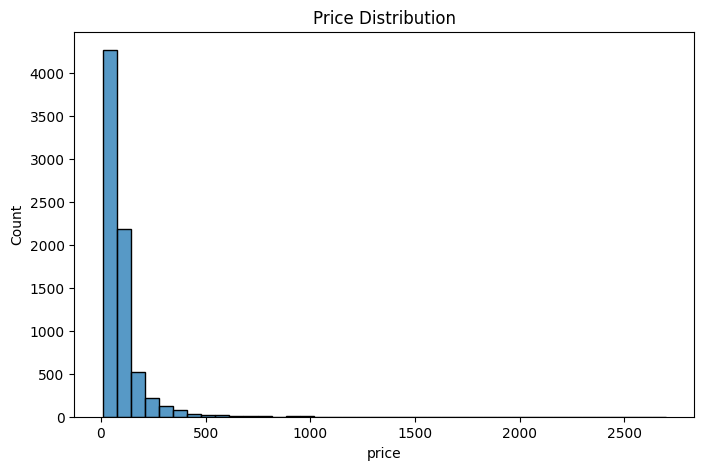

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data["price"], bins=40)

plt.title("Price Distribution")
plt.show()

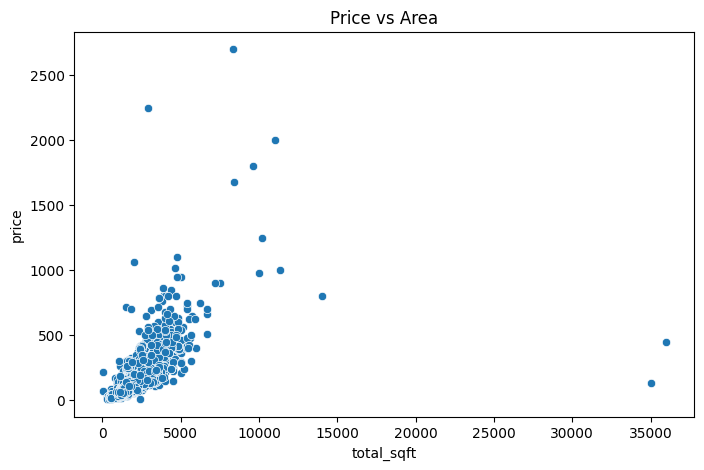

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=data["total_sqft"],
    y=data["price"]
)

plt.title("Price vs Area")
plt.show()

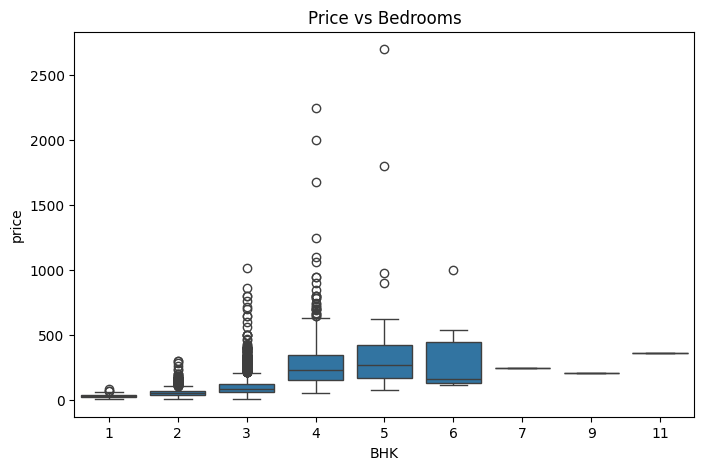

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=data["BHK"],
    y=data["price"]
)

plt.title("Price vs Bedrooms")
plt.show()

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = data[(df[column] >= lower_bound) & (data[column] <= upper_bound)]
    return df_cleaned

# Remove outliers from 'price' column
df = remove_outliers_iqr(data, 'price')

# Remove outliers from 'total_sqft' column
df = remove_outliers_iqr(data, 'total_sqft')

print(f"DataFrame shape after outlier removal: {df.shape}")

DataFrame shape after outlier removal: (6912, 10)


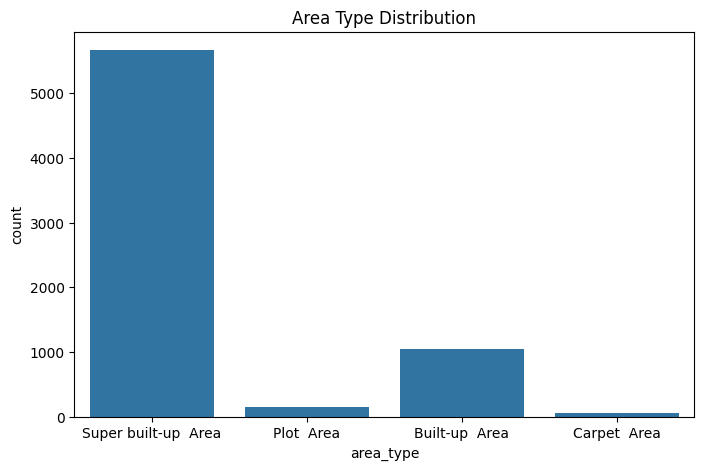

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["area_type"]
)

plt.title("Area Type Distribution")

plt.show()

In [ ]:
x = data[[
    "total_sqft",
    "bath",
    "balcony",
    "BHK"
]]
y = data["price"]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

x_train['total_sqft'] = x_train['total_sqft'].apply(convert_sqft)

x_train_cleaned = x_train.dropna(subset=['total_sqft'])
y_train_cleaned = y_train.loc[x_train_cleaned.index]

model.fit(x_train_cleaned, y_train_cleaned)

LinearRegression()

In [ ]:
x_test['total_sqft'] = x_test['total_sqft'].apply(convert_sqft)

# Drop rows where 'total_sqft' became NaN after conversion
x_test_cleaned = x_test.dropna(subset=['total_sqft'])

# Ensure y_test is aligned if needed for evaluation later
y_test_cleaned = y_test.loc[x_test_cleaned.index]

predictions = model.predict(x_test_cleaned)
predictions

array([ 80.2841517 ,  69.19392885, 281.00625057, ...,  74.51493232,
       147.22086231,  63.44256681])

In [ ]:
import gradio as gr

def predict_price(area, bathrooms, balcony, bhk):
    input_data = [[area, bathrooms, balcony, bhk]]
    prediction = model.predict(input_data)[0]
    return round(prediction, 2)

interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Area (Square Feet)"),
        gr.Number(label="Bathrooms"),
        gr.Number(label="Balcony"),
        gr.Number(label="Bedrooms (BHK)")
    ],
    outputs="number",
    title="House Price Prediction",
    description="Predict house price using Linear Regression Model"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db54919cf35bf8291c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
